. What is SVM?
SVM = Support Vector Machine

SVM is a supervised machine learning algorithm mainly used for classification.

Imagine we have two groups:

🔵 🔵 🔵          🔴 🔴 🔴
🔵 🔵 🔵          🔴 🔴 🔴
We want to draw a line that separates them:

🔵 🔵 🔵   |   🔴 🔴 🔴
🔵 🔵 🔵   |   🔴 🔴 🔴
SVM tries to find a good boundary between the classes.



 Class A       |       Class B

 ● ● ●         |         ○ ○ ○
 ● ● ●         |         ○ ○ ○
 ● ● ●         |         ○ ○ ○

              ↑
          Hyperplane

In [ ]:
The important idea: Margin
This is the most important concept for today.

Suppose we have:

🔵 🔵 🔵

       |        ← boundary

             🔴 🔴 🔴
There are many possible boundaries.

SVM doesn't simply choose any boundary.

It tries to find a boundary with a large margin.

The margin is the distance between the boundary and the closest data points

In [4]:
from sklearn import svm
# Training data
X = [
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 7],
    [7, 8],
    [8, 8]
]

# Labels
y = [
    0,
    0,
    0,
    1,
    1,
    1
]
model = svm.SVC(kernel="linear")

model.fit(X, y)

prediction = model.predict([
    [2,2],
    [7,7]
])
print(prediction)

[0 1]


SVM
 │
 ├── Hyperplane → boundary
 │
 ├── Margin → فاصله امن
 │
 ├── Support Vectors → نزدیک‌ترین نقاط
 │
 └── Classification → تقسیم کلاس‌ها

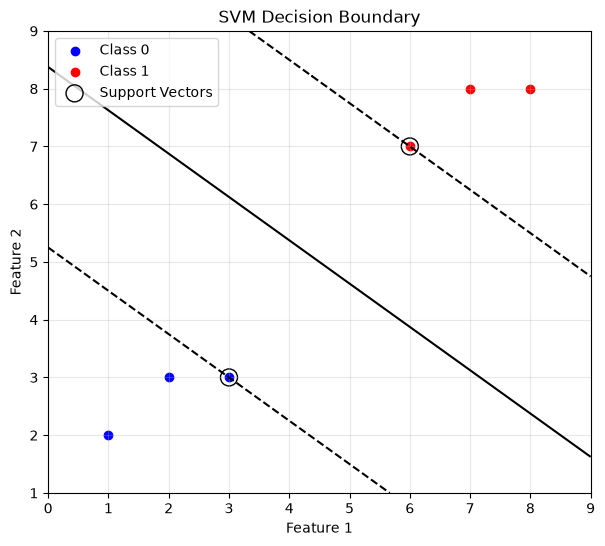

In [5]:
import matplotlib.pyplot as plt
import numpy as np

X = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 7],
    [7, 8],
    [8, 8]
])
y = np.array([0, 0, 0, 1, 1, 1])

model = svm.SVC(kernel="linear")
model.fit(X, y)

plt.figure(figsize=(7, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Class 1')
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
            facecolors='none', edgecolors='black', s=150, label='Support Vectors')

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors='k')
plt.title('SVM Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
